#### STEP 1 · BUILD WITH AI
#### Food Delivery Dataset EDA

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Generate synthetic dataset

In [7]:
np.random.seed(42)


''' Generate synthetic dataset '''

n = 300

cuisine_types = ["Indian", "Chinese", "Italian", "Mexican", "American"]

df = pd.DataFrame({
    "Order_Value": np.random.randint(100, 1000, n),
    "Delivery_Time": np.random.randint(15, 90, n),
    "Distance_km": np.round(np.random.uniform(1, 15, n), 2),
    "Delivery_Fee": np.random.randint(20, 150, n),
    "Discount_pct": np.random.randint(0, 30, n),
    "Cuisine_Type": np.random.choice(cuisine_types, n)
})

df.head()

,Order_Value,Delivery_Time,Distance_km,Delivery_Fee,Discount_pct,Cuisine_Type
0,202,73,14.56,54,6,Chinese
1,535,84,10.63,24,8,Indian
2,960,17,12.72,102,18,Chinese
3,370,34,13.14,142,15,Mexican
4,206,73,12.74,97,7,Mexican


#### Seaborn Pairplot of numeric columns coloured by Cuisine_Type

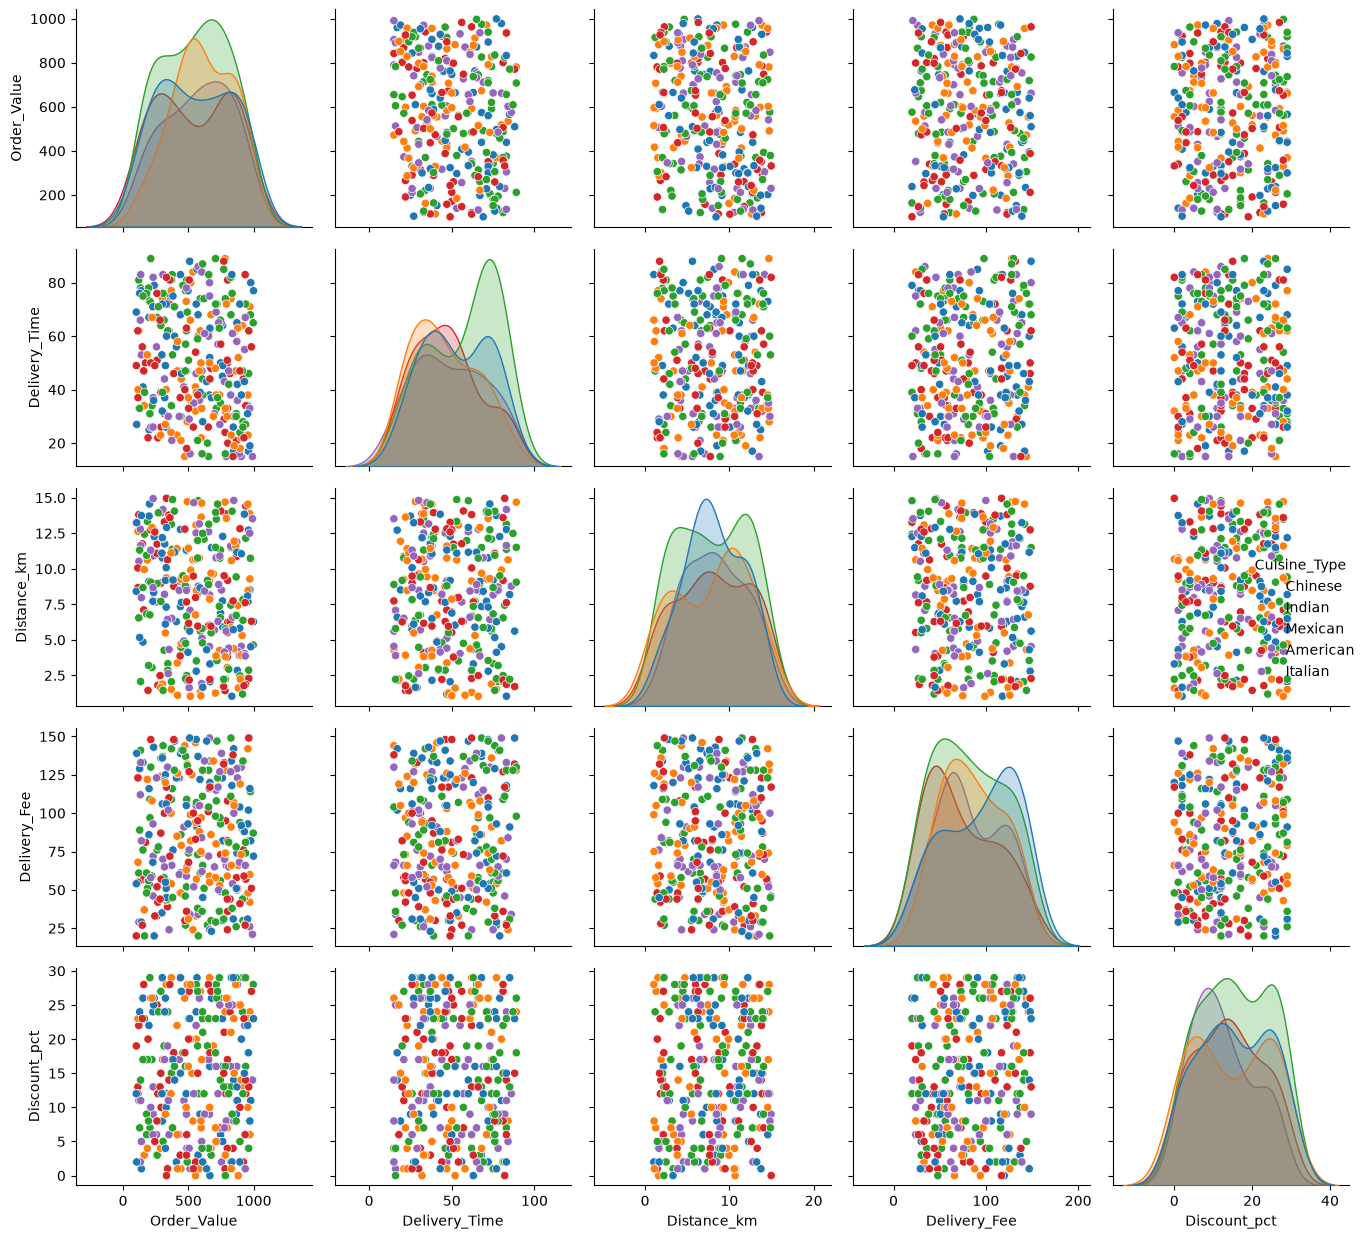

In [8]:
sns.pairplot(df, hue="Cuisine_Type")
plt.savefig("pairplot_numeric_by_cuisine.png", dpi=200)
plt.tight_layout()
plt.show()
plt.close()

#### Pearson correlation heatmap

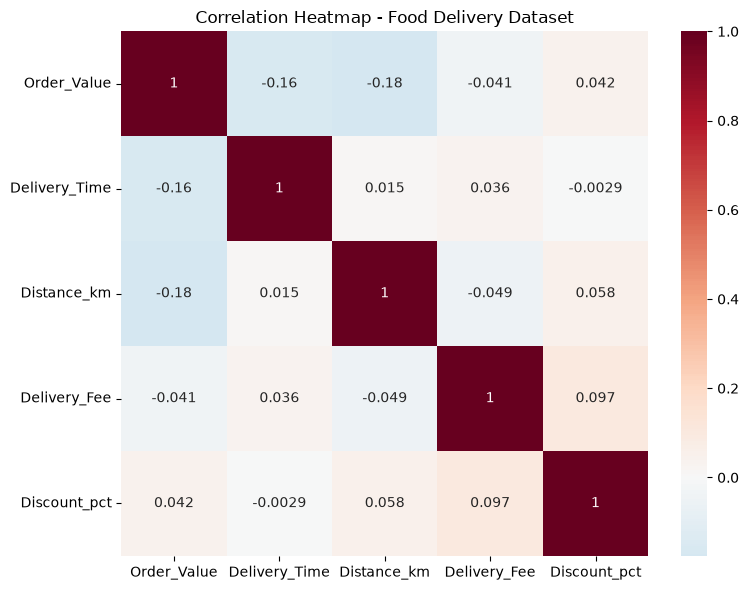

In [9]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0)
plt.title("Correlation Heatmap - Food Delivery Dataset")
plt.tight_layout()
plt.savefig("correlation_heatmap_food_delivery.png", dpi=200)
plt.show()
plt.close()

#### STEP 2 · TEST & DEBUG  (WITHOUT AI)
#### There's one possible limitation that should be fixed
**Pairplot breaks** if Cuisine_Type has missing values.
Seaborn’s pairplot doesn’t handle NaN in the hue column gracefully — it can throw errors or skip rows. 

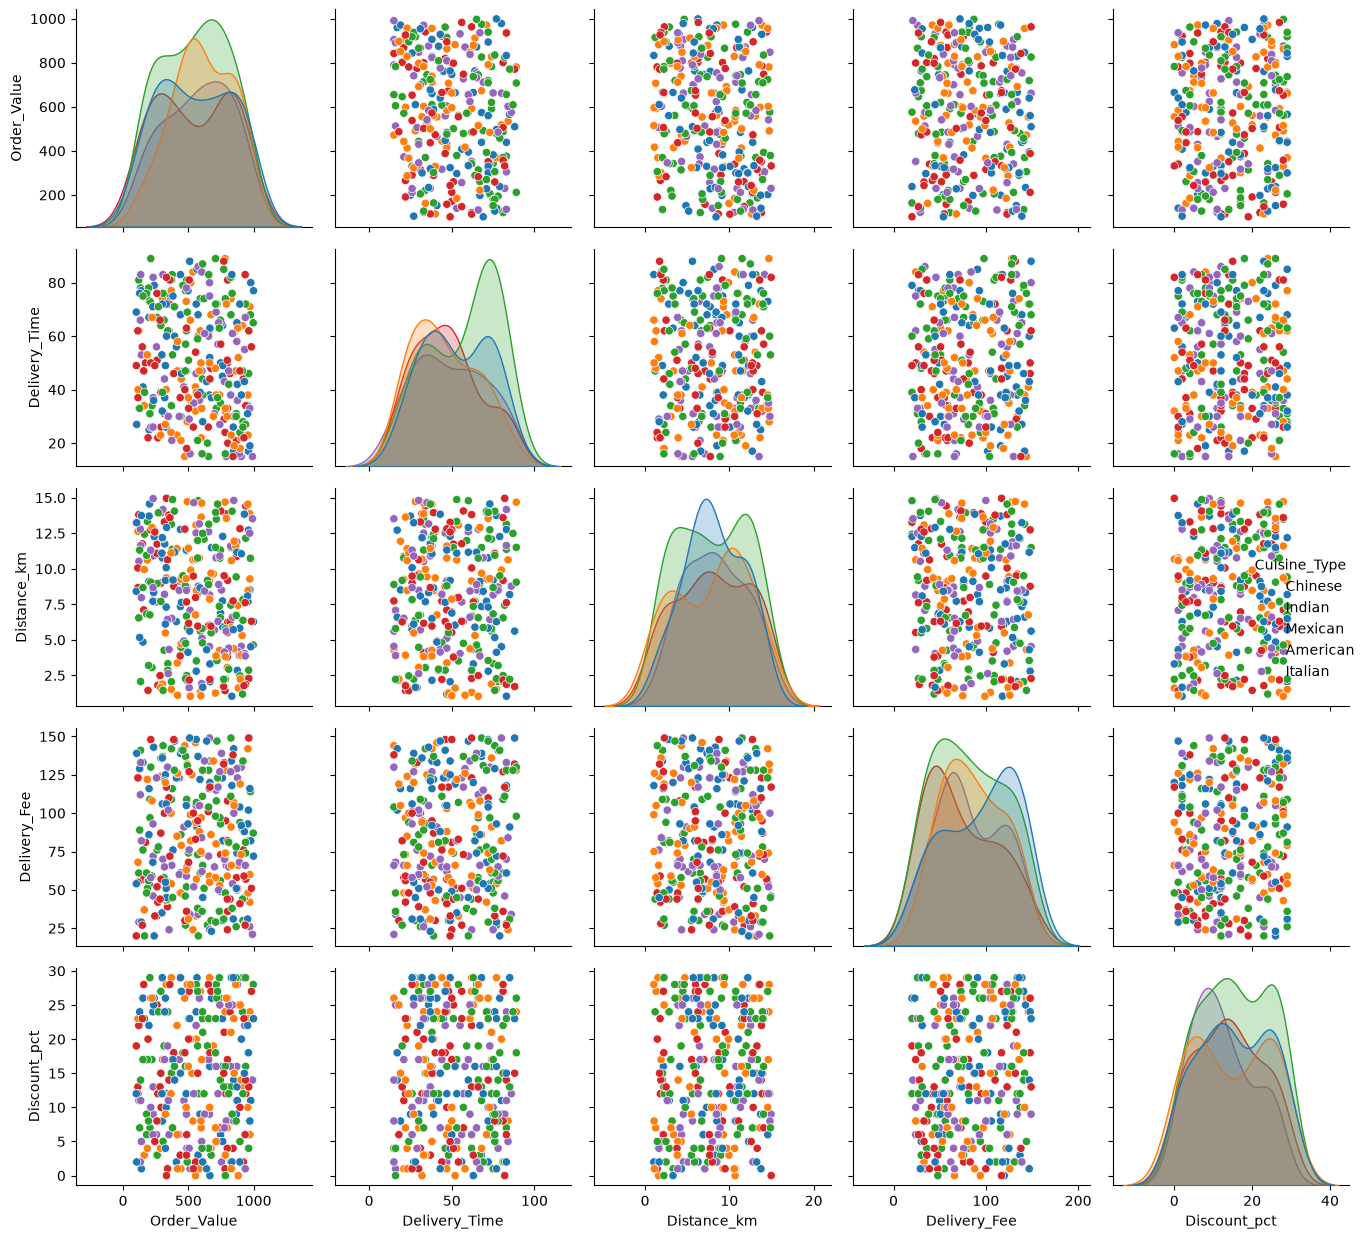

In [10]:
# Ensure no nulls in Cuisine_Type
df["Cuisine_Type"] = df["Cuisine_Type"].fillna("Unknown")

sns.pairplot(df, hue="Cuisine_Type")
plt.savefig("pairplot_numeric_by_cuisine.png", dpi=200)
plt.tight_layout()
plt.show()
plt.close()
